# Exploración de `data` e `item`

Este notebook cruza la tabla de calificaciones (`data`) con la tabla de películas (`item`) para
responder una sola pregunta general: **¿las características de una película se relacionan con la forma en
que se califica?**

Igual que en `user.ipynb`, se distinguen dos aspectos:

* **cuánto** se califica una película (popularidad, número de calificaciones);
* **qué tan alto** se califica (nivel de la calificación).

No se usa información demográfica de los usuarios (`user`): eso corresponde a los notebooks `data_user.ipynb`
y `data_item_user.ipynb` de otros integrantes.

## 1. Importación de librerías y datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
data_item = pd.read_csv("../../data/processed/data_item.csv", parse_dates=["datetime"])
data_item["release_dt"] = pd.to_datetime(data_item["release_date"])

print(f"data_item: {data_item.shape[0]} filas, {data_item.shape[1]} columnas")
print(f"Calificaciones entre {data_item['datetime'].min().date()} y {data_item['datetime'].max().date()}")
print(f"Películas distintas con al menos una calificación: {data_item['item_id'].nunique()}")
print(f"Usuarios distintos: {data_item['user_id'].nunique()}")
data_item.head()

data_item: 99455 filas, 27 columnas
Calificaciones entre 1997-09-20 y 1998-04-22
Películas distintas con al menos una calificación: 1661
Usuarios distintos: 943


,user_id,item_id,rating,timestamp,datetime,title,release_date,unknown,Action,Adventure,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,release_dt
0,1,1,5,874965758,1997-09-22 22:02:38,Toy Story (1995),1995-01-01,0,0,0,...,0,0,0,0,0,0,0,0,0,1995-01-01
1,1,2,3,876893171,1997-10-15 05:26:11,GoldenEye (1995),1995-01-01,0,1,1,...,0,0,0,0,0,0,1,0,0,1995-01-01
2,1,3,4,878542960,1997-11-03 07:42:40,Four Rooms (1995),1995-01-01,0,0,0,...,0,0,0,0,0,0,1,0,0,1995-01-01
3,1,4,3,876893119,1997-10-15 05:25:19,Get Shorty (1995),1995-01-01,0,1,0,...,0,0,0,0,0,0,0,0,0,1995-01-01
4,1,5,3,889751712,1998-03-13 01:15:12,Copycat (1995),1995-01-01,0,0,0,...,0,0,0,0,0,0,1,0,0,1995-01-01


**Nota sobre el origen del archivo:** a diferencia de `user.ipynb`, aquí no se dispone por separado del
archivo `item.csv` (solo del ya cruzado `data_item.csv`), así que la validación de la fusión no puede
rehacerse desde cero. En su lugar se comprueba la integridad de la fusión ya hecha: cada `item_id` debe
tener siempre el mismo título, la misma fecha de estreno y los mismos géneros en todas las filas donde
aparece; si eso no se cumpliera, sería señal de que el merge original mezcló datos de películas distintas.

## 2. Validación de la integridad del cruce

In [3]:
GENEROS = ["unknown", "Action", "Adventure", "Animation", "Children's", "Comedy", "Crime",
           "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
           "Romance", "Sci-Fi", "Thriller", "War", "Western"]

columnas_fijas = ["title", "release_date"] + GENEROS
variacion_por_item = data_item.groupby("item_id")[columnas_fijas].nunique()
inconsistentes = (variacion_por_item > 1).any(axis=1).sum()

print(f"Nulos totales en el archivo: {data_item.isnull().sum().sum()}")
print(f"Pares (user_id, item_id) duplicados: {data_item.duplicated(subset=['user_id', 'item_id']).sum()}")
print(f"Películas con metadatos inconsistentes entre sus filas: {inconsistentes} de "
      f"{data_item['item_id'].nunique()}")

n_generos_por_fila = data_item[GENEROS].sum(axis=1)
print(f"Filas sin ningún género marcado: {(n_generos_por_fila == 0).sum()}")
print(f"Rango de géneros marcados por película: {n_generos_por_fila.min()}–{n_generos_por_fila.max()}")

Nulos totales en el archivo: 0
Pares (user_id, item_id) duplicados: 0
Películas con metadatos inconsistentes entre sus filas: 0 de 1661
Filas sin ningún género marcado: 0
Rango de géneros marcados por película: 1–6


**Resultados:** no hay valores nulos, no hay pares usuario-película duplicados y las 1 661 películas
tienen metadatos perfectamente constantes en todas sus apariciones — el cruce es íntegro. El catálogo
completo de MovieLens 100k tiene 1 682 películas; las 21 que faltan aquí simplemente no recibieron ninguna
calificación, por lo que no aparecen en un archivo construido a partir de `data`.

**Conclusión:** se puede trabajar directamente sobre `data_item.csv` con la misma confianza que si se
hubiera rehecho el merge desde cero.

## 3. Nota metodológica: unidad de análisis

In [4]:
GENEROS_A_PROBAR = [g for g in GENEROS if g != "unknown"]  # unknown solo tiene 1 película

perfil = (
    data_item.groupby("item_id")
    .agg(
        title=("title", "first"),
        release_dt=("release_dt", "first"),
        n_calificaciones=("rating", "size"),
        calificacion_media=("rating", "mean"),
        **{g: (g, "max") for g in GENEROS}
    )
)
perfil["release_year"] = perfil["release_dt"].dt.year
perfil["antiguedad_media_dias"] = (
    data_item.assign(gap=(data_item["datetime"] - data_item["release_dt"]).dt.days)
    .groupby("item_id")["gap"].mean()
)

# Diccionario donde se guardan los p-valores para corregirlos al final (sección 8)
pruebas = {}

print(f"Perfil de películas: {perfil.shape[0]} filas (una por película)")
perfil[["title", "release_year", "n_calificaciones", "calificacion_media"]].head()

Perfil de películas: 1661 filas (una por película)


,title,release_year,n_calificaciones,calificacion_media
item_id,,,,
1,Toy Story (1995),1995,452,3.878319
2,GoldenEye (1995),1995,131,3.206107
3,Four Rooms (1995),1995,90,3.033333
4,Get Shorty (1995),1995,209,3.550239
5,Copycat (1995),1995,86,3.302326


La tabla cruzada tiene **99 455 filas pero solo 1 661 películas**. Igual que ocurría con los usuarios en
`user.ipynb`, las calificaciones de una misma película no son independientes entre sí: una película con
583 calificaciones pesa 583 veces más que una con solo 1 en cualquier promedio calculado sobre las filas
crudas, y todas esas filas comparten el mismo título, año y géneros. Aplicar una prueba estadística sobre
las 99 455 filas trataría esas repeticiones como observaciones nuevas y produciría p-valores artificialmente
pequeños (pseudorreplicación) — el mismo problema que con los usuarios, ahora del lado de las películas.

Además, los géneros **no son mutuamente excluyentes**: 839 de las 1 661 películas tienen más de un género
marcado. Por eso no tiene sentido una única prueba de Kruskal-Wallis "género vs. calificación" como se hizo
con la ocupación de los usuarios (los grupos se solaparían). En su lugar, cada género se compara por
separado contra "el resto" (Mann-Whitney de dos muestras), género por género.

Regla adoptada en todo el notebook:

* **Descripción** (promedios globales, distribución de la actividad): a nivel de **calificación**,
  n = 99 455.
* **Inferencia** (toda prueba, correlación e intervalo de confianza): a nivel de **película**, n = 1 661,
  agregando primero cada película a sus indicadores: **calificación media** y **número de
  calificaciones**.

### Funciones auxiliares

In [5]:
def cliffs_delta(a, b):
    """Tamaño del efecto no paramétrico. |d| < 0.147 despreciable, < 0.33 pequeño, < 0.474 mediano."""
    u, _ = stats.mannwhitneyu(a, b, alternative="two-sided")
    return 2 * u / (len(a) * len(b)) - 1


def ic95_media(x):
    """IC del 95% para la media, basado en la t de Student."""
    x = np.asarray(x, dtype=float)
    margen = stats.sem(x) * stats.t.ppf(0.975, len(x) - 1)
    return x.mean() - margen, x.mean() + margen


def holm(p_valores):
    """Corrección de Holm-Bonferroni para comparaciones múltiples."""
    ordenados = sorted(p_valores.items(), key=lambda par: par[1])
    m = len(ordenados)
    ajustados, maximo_previo = {}, 0.0
    for i, (nombre, p) in enumerate(ordenados):
        maximo_previo = max(maximo_previo, min(1.0, (m - i) * p))
        ajustados[nombre] = maximo_previo
    return ajustados

## 4. Popularidad: cuántas calificaciones recibe cada película

**Qué se calcula:** descriptivos y concentración del número de calificaciones por película.

**Por qué es relevante:** determina cuánto pesa cada película en cualquier promedio global calculado sobre
las 99 455 filas, y es el punto de partida para la relación entre popularidad y calidad de la sección 5.

In [6]:
popularidad = perfil["n_calificaciones"]
q1, q3 = popularidad.quantile([0.25, 0.75])
iqr = q3 - q1
atipicos = popularidad[(popularidad < q1 - 1.5 * iqr) | (popularidad > q3 + 1.5 * iqr)]

print(popularidad.describe().round(2), "\n")
print(f"Asimetría: {popularidad.skew():.2f} | IQR: {iqr:.0f}"
      f" | películas atípicas (1.5*IQR): {atipicos.size} (todas por exceso de popularidad)")

n_top = int(round(perfil.shape[0] * 0.10))
top_populares = popularidad.sort_values(ascending=False).head(n_top)
mitad_menos_vista = popularidad.sort_values().head(perfil.shape[0] // 2)
print(f"\nEl 10% más popular ({n_top} películas) recibe el {top_populares.sum() / popularidad.sum() * 100:.1f}%"
      f" de las calificaciones")
print(f"La mitad menos vista ({perfil.shape[0] // 2} películas) recibe apenas el"
      f" {mitad_menos_vista.sum() / popularidad.sum() * 100:.1f}%")

count    1661.00
mean       59.88
std        80.71
min         1.00
25%         7.00
50%        27.00
75%        80.00
max       583.00
Name: n_calificaciones, dtype: float64

 

Asimetría: 2.30 | IQR: 73 | películas atípicas (1.5*IQR): 129 (todas por exceso de popularidad)

El 10% más popular (166 películas) recibe el 42.6% de las calificaciones
La mitad menos vista (830 películas) recibe apenas el 7.3%


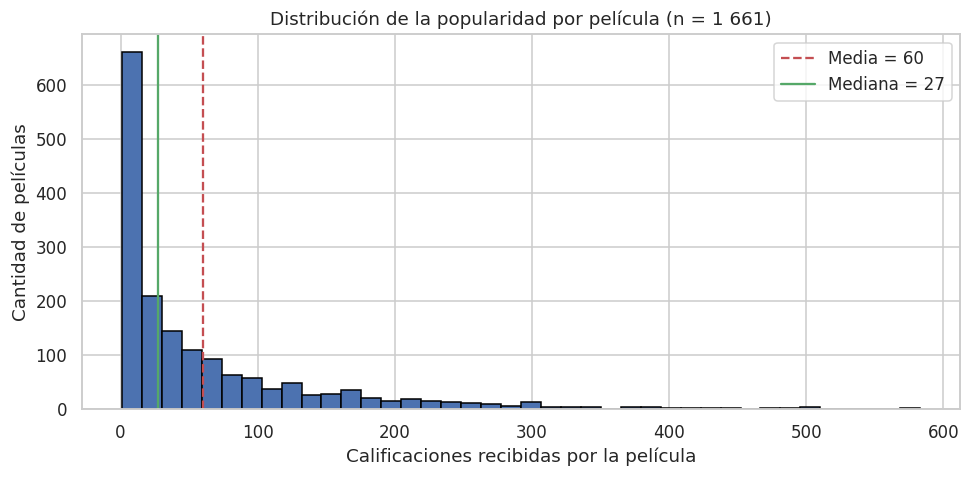

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(popularidad, bins=40, color="#4C72B0", edgecolor="black")
ax.axvline(popularidad.mean(), color="#C44E52", linestyle="--",
           label=f"Media = {popularidad.mean():.0f}")
ax.axvline(popularidad.median(), color="#55A868", linestyle="-",
           label=f"Mediana = {popularidad.median():.0f}")
ax.set_xlabel("Calificaciones recibidas por la película")
ax.set_ylabel("Cantidad de películas")
ax.set_title("Distribución de la popularidad por película (n = 1 661)")
ax.legend()
fig.tight_layout()
plt.show()

**Resultados:** mediana de 27 calificaciones por película frente a una media de 59.9 (asimetría 2.3); el
rango va de 1 a 583 y hay 129 películas atípicas, todas por exceso de popularidad. El 10 % más popular
(166 películas) concentra el 42.6 % de todas las calificaciones, mientras que la mitad menos vista apenas
llega al 7.3 %.

**Conclusión:** la popularidad está **incluso más concentrada** que la actividad de los usuarios en
`user.ipynb`. Confirma la necesidad de trabajar a nivel de película (n = 1 661) para cualquier comparación
entre grupos, y anticipa la relación de la siguiente sección: un puñado de películas domina por completo
las 99 455 filas.

## 5. Popularidad y calidad: ¿las películas más vistas son las mejor calificadas?

**Qué se calcula:** correlación de **Spearman** entre el número de calificaciones y la calificación media
de cada película.

**Hipótesis:** H₀: ρ = 0 (no hay asociación monótona entre popularidad y calidad percibida).

**Por qué Spearman:** ambas variables están fuertemente sesgadas (la popularidad, según la sección 4) y no
se asume ninguna forma lineal concreta entre ellas.

In [8]:
rho_pop, p_pop = stats.spearmanr(perfil["n_calificaciones"], perfil["calificacion_media"])
pruebas["Spearman popularidad ~ calificación media"] = p_pop

print(f"Spearman nº calificaciones ~ calificación media: rho = {rho_pop:.3f} | p = {p_pop:.2e}")

Spearman nº calificaciones ~ calificación media: rho = 0.503 | p = 4.78e-107


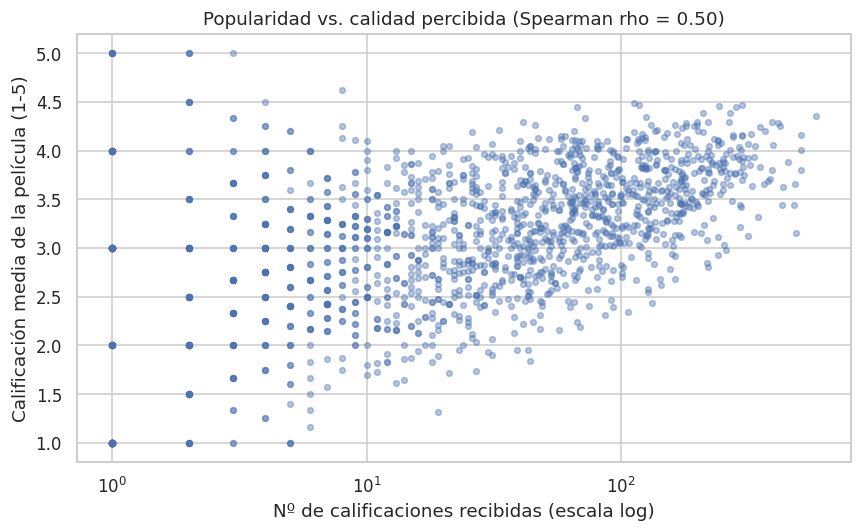

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(perfil["n_calificaciones"], perfil["calificacion_media"], s=14, alpha=0.4, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("Nº de calificaciones recibidas (escala log)")
ax.set_ylabel("Calificación media de la película (1-5)")
ax.set_title(f"Popularidad vs. calidad percibida (Spearman rho = {rho_pop:.2f})")
fig.tight_layout()
plt.show()

**Resultados:** **ρ = 0.503** (p < 0.001), una asociación moderada y claramente la más fuerte de todo el
notebook: cuanto más vista es una película, más alta tiende a ser su calificación media.

**Conclusión:** esto **no** significa necesariamente que "ver más una película la mejora". Es más plausible
un efecto de selección: la gente elige qué ver guiada por recomendaciones y reputación previa, así que las
películas malas tienden a filtrarse antes de acumular muchas calificaciones (y las pocas personas que sí las
ven ya sabían más o menos a qué atenerse). Es la misma cautela de siempre: correlación fuerte no implica que
la dirección causal sea "más vistas → mejor calificadas".

## 6. Calificación por género de película

**Qué se calcula:** para cada género, se compara la calificación media de las películas que pertenecen a
ese género contra las que no, con **Mann-Whitney** y tamaño del efecto (delta de Cliff). Se excluye
`unknown` (solo 1 película).

**Hipótesis (por género):** H₀: la distribución de la calificación media es igual dentro y fuera del
género. H₁: difiere.

**Por qué comparaciones separadas y no una única prueba:** como se explicó en la sección 3, los géneros se
solapan (una película puede ser Comedia y Romance a la vez), así que no forman grupos mutuamente
excluyentes válidos para un solo Kruskal-Wallis.

In [10]:
filas_genero = []
for genero in GENEROS_A_PROBAR:
    en_genero = perfil.loc[perfil[genero] == 1, "calificacion_media"]
    fuera_genero = perfil.loc[perfil[genero] == 0, "calificacion_media"]
    _, p = stats.mannwhitneyu(en_genero, fuera_genero, alternative="two-sided")
    delta = cliffs_delta(en_genero, fuera_genero)
    pruebas[f"MW calificación media ~ género {genero}"] = p
    filas_genero.append((genero, len(en_genero), en_genero.mean(), fuera_genero.mean(), p, delta))

tabla_generos = pd.DataFrame(
    filas_genero,
    columns=["género", "n_películas", "media_en_género", "media_fuera", "p", "delta_cliff"],
).sort_values("p").reset_index(drop=True)
tabla_generos.round(4)

,género,n_películas,media_en_género,media_fuera,p,delta_cliff
0,Drama,714,3.1895,2.9954,0.0000,0.1787
1,War,71,3.4892,3.0605,0.0000,0.3481
2,Horror,90,2.7202,3.0994,0.0000,-0.2939
3,Romance,244,3.2490,3.0495,0.0001,0.1563
4,Children's,120,2.9141,3.0917,0.0003,-0.1975
5,Film-Noir,24,3.5484,3.0719,0.0003,0.4279
6,Comedy,502,3.0063,3.1102,0.0005,-0.1075
7,Action,249,2.9690,3.0982,0.0016,-0.1252
8,Musical,56,3.3764,3.0684,0.0017,0.2467
9,Mystery,60,3.3534,3.0685,0.0019,0.2357


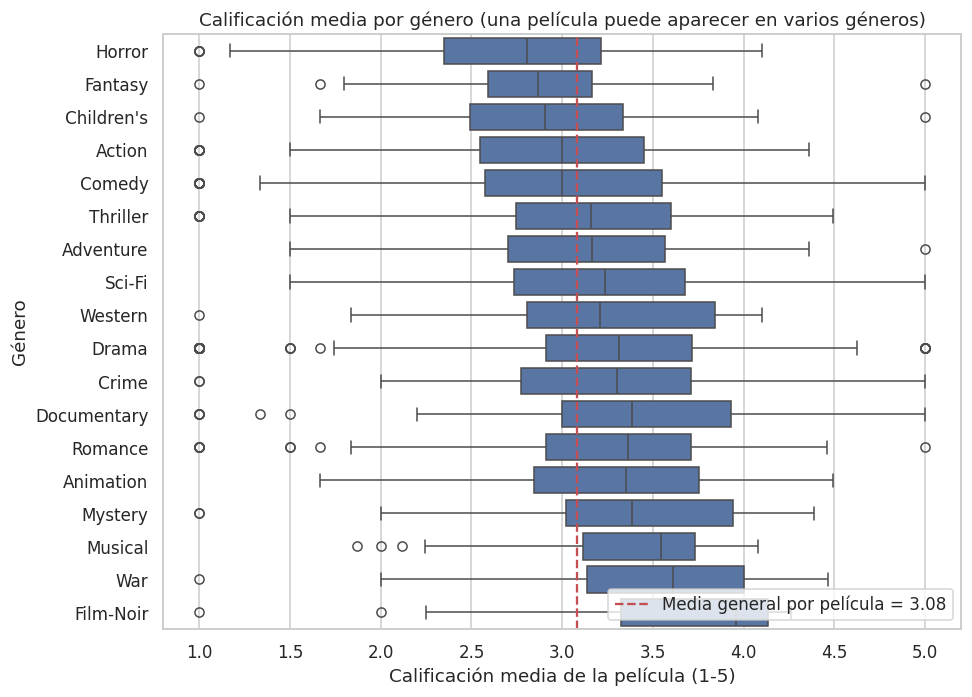

In [11]:
orden = tabla_generos.sort_values("media_en_género")["género"]
medias_genero = perfil.melt(
    id_vars="calificacion_media", value_vars=GENEROS_A_PROBAR,
    var_name="género", value_name="pertenece",
).query("pertenece == 1")

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.boxplot(data=medias_genero, y="género", x="calificacion_media", order=orden,
            color="#4C72B0", ax=ax)
ax.axvline(perfil["calificacion_media"].mean(), color="#C44E52", linestyle="--",
           label=f"Media general por película = {perfil['calificacion_media'].mean():.2f}")
ax.set_xlabel("Calificación media de la película (1-5)")
ax.set_ylabel("Género")
ax.set_title("Calificación media por género (una película puede aparecer en varios géneros)")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**Resultados (antes de corregir por comparaciones múltiples):** los géneros con diferencia más marcada
son Drama (media 3.19 vs. 3.00 fuera, delta = 0.18), Guerra (3.49 vs. 3.06, delta = 0.35), Terror (2.72 vs.
3.10, delta = -0.29), Romance (3.25 vs. 3.05) y Cine negro (3.55 vs. 3.07, delta = 0.43, aunque con solo 24
películas). Aventura, Sci-Fi, Thriller y Western no muestran diferencia apreciable.

**Conclusión:** hay géneros con una asociación real y de tamaño moderado con la calificación (Guerra, Cine
negro, Terror), pero varios de los que aparecen "significativos" en la tabla sin corregir tienen pocas
películas (Cine negro: 24; Fantasía: 22) y podrían no sobrevivir la corrección de la sección 8.

## 7. Año de estreno y calificación

**Qué se calcula:** correlación de Spearman entre el año de estreno de la película y su calificación
media, y entre el año de estreno y su popularidad. También la relación entre la **antigüedad de la
película en el momento en que fue calificada** (media de días transcurridos entre el estreno y cada
calificación que recibió) y su calificación media.

**Por qué es relevante:** distingue dos posibles narrativas: ¿las películas viejas se califican mejor
porque solo sobreviven en el catálogo las que ya eran buenas ("filtro del tiempo"), o el catálogo entero
recibió sus calificaciones en la misma ventana de siete meses (sept. 1997 - abr. 1998) y lo que varía es
solo qué tan "vieja" era cada película en ese momento?

In [12]:
rho_year_rating, p_year_rating = stats.spearmanr(perfil["release_year"], perfil["calificacion_media"])
rho_year_pop, p_year_pop = stats.spearmanr(perfil["release_year"], perfil["n_calificaciones"])
rho_antig, p_antig = stats.spearmanr(perfil["antiguedad_media_dias"], perfil["calificacion_media"])
pruebas["Spearman año de estreno ~ calificación media"] = p_year_rating
pruebas["Spearman año de estreno ~ popularidad"] = p_year_pop
pruebas["Spearman antigüedad al calificar ~ calificación media"] = p_antig

print(f"Año de estreno ~ calificación media: rho = {rho_year_rating:.3f} | p = {p_year_rating:.2e}")
print(f"Año de estreno ~ popularidad:        rho = {rho_year_pop:.3f} | p = {p_year_pop:.2e}")
print(f"Antigüedad al calificar ~ calificación media: rho = {rho_antig:.3f} | p = {p_antig:.2e}")
print(f"\nRango de años de estreno: {perfil['release_year'].min()}-{perfil['release_year'].max()}")

Año de estreno ~ calificación media: rho = -0.235 | p = 2.37e-22
Año de estreno ~ popularidad:        rho = -0.170 | p = 3.20e-12
Antigüedad al calificar ~ calificación media: rho = 0.232 | p = 7.99e-22

Rango de años de estreno: 1922-1998


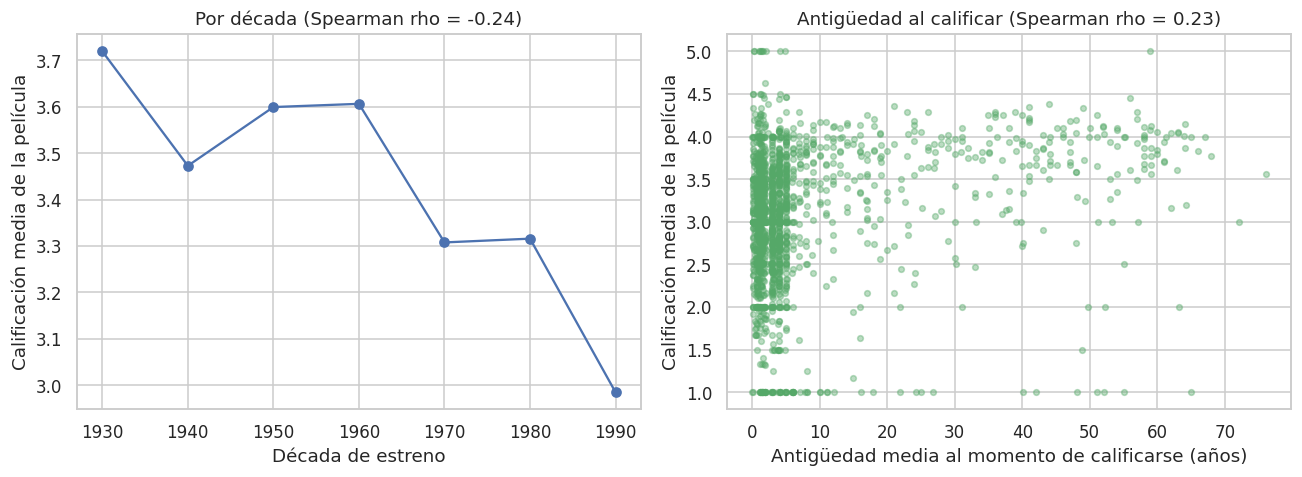

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

decada = (perfil["release_year"] // 10 * 10).astype(int)
resumen_decada = perfil.assign(decada=decada).groupby("decada")["calificacion_media"].agg(["mean", "size"])
resumen_decada = resumen_decada[resumen_decada["size"] >= 5]
ax1.plot(resumen_decada.index, resumen_decada["mean"], marker="o", color="#4C72B0")
ax1.set_xlabel("Década de estreno")
ax1.set_ylabel("Calificación media de la película")
ax1.set_title(f"Por década (Spearman rho = {rho_year_rating:.2f})")

ax2.scatter(perfil["antiguedad_media_dias"] / 365.25, perfil["calificacion_media"],
            s=14, alpha=0.4, color="#55A868")
ax2.set_xlabel("Antigüedad media al momento de calificarse (años)")
ax2.set_ylabel("Calificación media de la película")
ax2.set_title(f"Antigüedad al calificar (Spearman rho = {rho_antig:.2f})")

fig.tight_layout()
plt.show()

**Resultados:** el año de estreno se correlaciona negativamente con la calificación media (**ρ = -0.235**,
p < 0.001): las películas más viejas tienden a calificarse mejor. Consistente con esto, la antigüedad media
al momento de ser calificada se correlaciona positivamente (**ρ = 0.232**, p < 0.001). El año de estreno
también se asocia, más débilmente, con menor popularidad (ρ = -0.170): las películas viejas del catálogo
reciben en conjunto menos calificaciones que los estrenos recientes de 1997-1998.

**Conclusión:** ambos resultados apuntan al mismo fenómeno, coherente con el "filtro del tiempo": las
películas de hace décadas que siguen en el catálogo de 1998 y siguen siendo vistas son, en su mayoría,
clásicos que sobrevivieron por ser buenas — las mediocres de esa época simplemente ya no se veían. Esto no
es evidencia de que "las películas antiguas son objetivamente mejores", sino de un sesgo de supervivencia en
qué películas viejas llegan a calificarse.

## 8. Corrección por comparaciones múltiples

**Qué se calcula:** el ajuste de **Holm-Bonferroni** sobre los 21 p-valores obtenidos (18 por género +
3 de correlaciones).

**Por qué es relevante:** con 21 pruebas a α = 0.05, la probabilidad de al menos un falso positivo por azar
sube a más del 60 % si no se corrige. Holm controla esa tasa de error global.

In [14]:
ajustados = holm(pruebas)
tabla_pruebas = pd.DataFrame({
    "p_original": pd.Series(pruebas),
    "p_ajustado_holm": pd.Series(ajustados),
})
tabla_pruebas["significativo_5%"] = np.where(tabla_pruebas["p_ajustado_holm"] < 0.05, "sí", "no")
tabla_pruebas.sort_values("p_original").round(5)

,p_original,p_ajustado_holm,significativo_5%
Spearman popularidad ~ calificación media,0.00000,0.00000,sí
Spearman año de estreno ~ calificación media,0.00000,0.00000,sí
Spearman antigüedad al calificar ~ calificación media,0.00000,0.00000,sí
Spearman año de estreno ~ popularidad,0.00000,0.00000,sí
MW calificación media ~ género Drama,0.00000,0.00000,sí
MW calificación media ~ género War,0.00000,0.00001,sí
MW calificación media ~ género Horror,0.00000,0.00004,sí
MW calificación media ~ género Romance,0.00009,0.00141,sí
MW calificación media ~ género Children's,0.00031,0.00431,sí
MW calificación media ~ género Film-Noir,0.00031,0.00431,sí


**Resultados:** las tres correlaciones (popularidad-calidad, año-calidad, antigüedad-calidad) y los
géneros Drama, Guerra, Terror, Romance, Cine negro, Comedia, Niños, Acción, Musical y Misterio siguen siendo
significativos tras el ajuste. Fantasía y Documental, que estaban cerca de 0.05 sin corregir (p = 0.057 y
0.062), se vuelven claramente no significativos al ajustar — coherente con lo anticipado en la sección 6 por
su tamaño de muestra pequeño.

**Conclusión:** los hallazgos robustos de este notebook (que sobreviven la corrección) son: la fuerte
asociación entre popularidad y calidad, la tendencia de las películas viejas a calificarse mejor, y un
grupo estable de géneros con diferencias de tamaño pequeño a moderado — encabezado por Guerra y Cine negro
en el extremo alto y Terror en el extremo bajo.

## 9. Conclusiones y limitaciones

### Conclusiones

1. **El archivo `data_item.csv` es íntegro:** metadatos de película perfectamente constantes en las 99 455
   filas, sin duplicados ni nulos.
2. **La popularidad está incluso más concentrada que la actividad de los usuarios:** el 10 % de las
   películas más vistas acapara el 42.6 % de las calificaciones.
3. **Popularidad y calidad están moderadamente asociadas (ρ = 0.50):** las películas más vistas tienden a
   estar mejor calificadas, muy probablemente por selección del espectador más que por un efecto causal de
   "verse más".
4. **Las películas viejas del catálogo tienden a calificarse mejor** (ρ = -0.235 con el año de estreno),
   consistente con un sesgo de supervivencia: solo los clásicos siguen en circulación décadas después.
5. **El género sí importa, con tamaños de efecto pequeños a moderados:** Guerra y Cine negro se califican
   por encima del promedio; Terror, por debajo. La mayoría de los géneros (Aventura, Sci-Fi, Thriller,
   Western) no muestran diferencia apreciable.

### Limitaciones

* **Sin datos por separado de `item.csv`:** la validación de la sección 2 comprueba la integridad interna
  del archivo ya cruzado, no reconstruye el merge desde las tablas originales.
* **Géneros solapados:** una película puede pertenecer a varios géneros a la vez, así que las 18
  comparaciones de la sección 6 no son independientes entre sí — una película muy bien calificada en Drama
  y Romance simultáneamente "empuja" ambas pruebas.
* **Ventana de calificación corta y fija:** todas las calificaciones ocurrieron entre septiembre de 1997 y
  abril de 1998, así que "antigüedad al calificar" está determinada casi enteramente por la fecha de
  estreno, no por un proceso real de acumulación en el titemp.
* **Sin información de usuario:** este notebook no dice si son ciertos tipos de usuarios (por edad, género,
  ocupación) quienes impulsan estas diferencias por género de película — eso corresponde a
  `data_item_user.ipynb`.
* **Categorías pequeñas:** Cine negro (24 películas) y Fantasía (22) tienen intervalos de incertidumbre
  amplios; sus resultados deben leerse con cautela incluso cuando el p-valor es bajo.